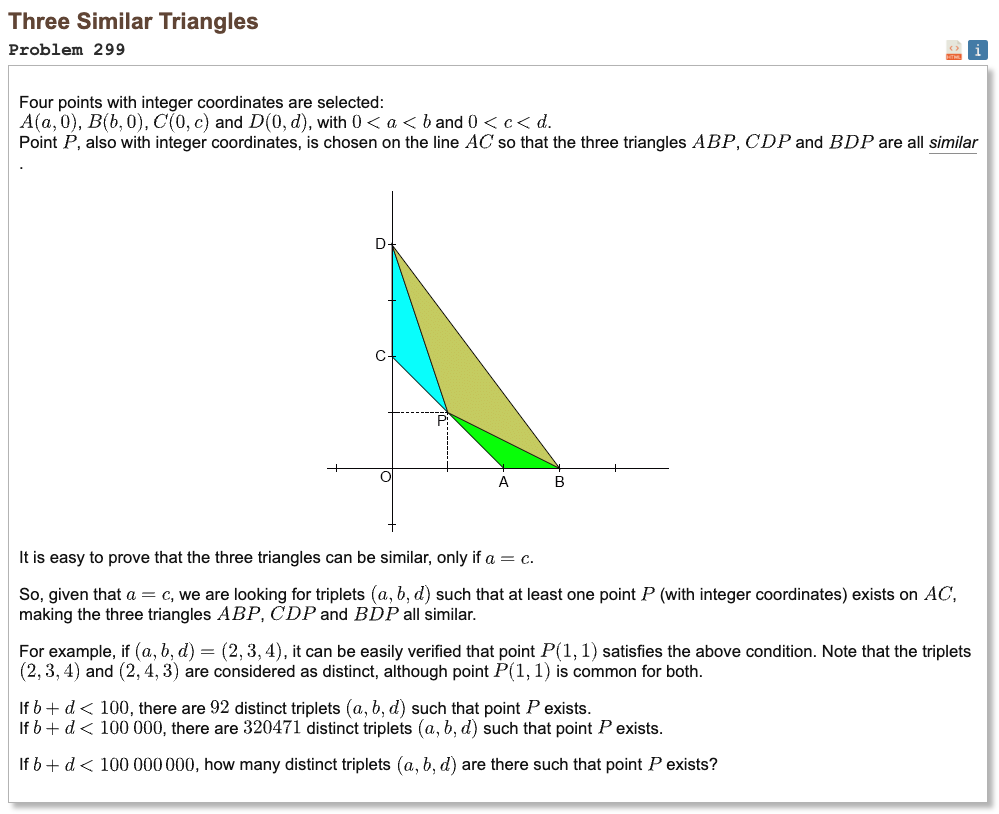

## Initial approach

* split the geometry into two completely different cases, and count them separately
* in the first case, the special point acts like the center of equal distance to the three sides of the triangle built from the axes and the two lower points
* that case turns into counting ordered Pythagorean leg pairs with a perimeter style bound
* so generate primitive Pythagorean triples once, then count how many scaled copies still fit the limit
* in the second case, the diagonal line and the segment between the lower points must be parallel
* that case turns into a Pell type family, so primitive solutions can be generated from two smaller parameters, then scaled the same way
* both families reduce to counting primitive generators and then adding the number of valid multiples

In [1]:
from math import gcd, isqrt

def solve(limit):
    total = 0

    m_limit = isqrt(limit)

    for m in range(2, m_limit + 1):
        for n in range(1, m):
            if ((m - n) & 1) == 0 or gcd(m, n) != 1:
                continue

            x = m * m - n * n
            y = 2 * m * n
            s = x + y
            if s >= limit:
                continue

            total += 2 * ((limit - 1) // s)

    uv_limit = isqrt(limit // 2) + 2

    for u in range(1, uv_limit + 1, 2):
        for v in range(1, uv_limit + 1):
            if gcd(u, v) != 1:
                continue

            b0 = u * u + 2 * v * v + 2 * u * v
            if 2 * b0 >= limit:
                continue

            total += (limit - 1) // (2 * b0)

    return total

assert solve(100) == 92
assert solve(100000) == 320471

In [2]:
%%time
result = solve(100000000)
print("Result:", result)

Result: 549936643
CPU times: user 7.99 s, sys: 50.4 ms, total: 8.04 s
Wall time: 8.11 s
